# Lecture : Shallow Graph Learning

## Lab 05 : Introduction to Graphs with DGL, PyG, NetworkX, PyTorch - Solution

### Xavier Bresson, Guoji Fu  

<br>
Notebook goals :<br>  
• Build graphs with Deep Graph Library (DGL) [1] and PyTorch Geometric (PyG) [2] <br>  
• Compute the same message-passing function with DGL and PyG <br>  
• Create batches of DGL and PyG graphs <br>  
• Convert DGL/PyG graphs to NetworkX graphs for visualization w/ balanced springs system [3] <br>
• Convert DGL/PyG graphs to PyTorch graphs for visualization w/ Laplacian eigenvectors [4] <br>
• Conversions between DGL, PyG, NetworkX, and (dense and sparse) PyTorch graphs <br><br>  

[1] Wang et-al, Deep graph library: A graph-centric, highly-performant package for graph neural networks, 2019  
https://www.dgl.ai  
[2] Fey, Lenssen, Fast Graph Representation Learning with PyTorch Geometric, 2019  
https://pytorch-geometric.readthedocs.io  
[3] Kamada, Kawai, An algorithm for drawing general undirected graphs, 1989  
https://shorturl.at/fpDV2    
[4] Belkin, Niyogi, Laplacian eigenmaps for dimensionality reduction and data representation, 2003  
http://graphics.stanford.edu/courses/cs233-20-spring/ReferencedPapers/Laplacian.pdf


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/05_Shallow_Learning'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip -q install -f https://data.dgl.ai/wheels/torch-2.6/repo.html dgl==2.5.0 # Install DGL
    !pip install torch_geometric==2.5.1 # Install PyG
    

In [2]:
# Libraries
import dgl # Deep Graph Library (DGL)
import torch_geometric # PyTorch Geometric (PyG)
from torch_geometric.nn import MessagePassing
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("DGL:", dgl.__version__)


PyTorch: 2.1.2
PyG: 2.5.1
DGL: 1.0.2


## Exercise 1 : Build a graph with Deep Graph Library (DGL) & PyTorch Geometric (PyG)

### Question 1.1 : Create a cycle graph of 7 nodes with DGL and convert it to a bidirectional graph

Instructions:
- Use `dgl.graph(data, num_nodes=None)` to create the graph in DGL.  
- The graph is initialized with two lists: one containing the source node indices and the other containing the corresponding destination indices. These lists define all the edges in the graph.
- To convert the directed graph into an undirected (bidirectional) graph, you can use `dgl.to_bidirected(graph)`.


In [3]:
list_src = []
list_dst = []
num_nodes = 7
for i in range(num_nodes):
    list_src.append(i)
    list_dst.append((i+1)%num_nodes)
print([list_src,list_dst])

###############################################
# YOUR CODE START
###############################################

# create DGL graph
orig_graph_dgl = dgl.graph((list_src, list_dst))

# convert the graph to a symmetrize/undirected graph
graph_dgl = dgl.to_bidirected(orig_graph_dgl)

###############################################
# YOUR CODE END
###############################################

print(graph_dgl)


[[0, 1, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5, 6, 0]]
Graph(num_nodes=7, num_edges=14,
      ndata_schemes={}
      edata_schemes={})


### Question 1.2 : Add node and edge features to the previously defined DGL graph

Add node in-degrees as the node features and random features as the edge features to the DGL graph.

Instructions:
- Let `g = dgl.graph(data)` be the DGL graph.
- To add node features (e.g. 'in-degree'), use `g.ndata['feat_name']`, where `'feat_name'` is the name of the feature you wish to assign.
- To add edge features, use `g.edata['feat_name']`, where `'feat_name'` corresponds to the feature name for the edges.
- To compute the in-degrees for the nodes, use `g.in_degrees().view(-1, 1).float()`. This will return a tensor of the in-degrees for each node.
- To generate random edge features, use `torch.rand(g.num_edges(), 100)`, which creates random features with 100 dimensions for each edge.
- You can obtain the number of edges using `g.num_edges()`.


In [4]:
###############################################
# YOUR CODE START
###############################################

# Add node in-degrees as node features to the DGL graph
graph_dgl.ndata['feat'] = graph_dgl.in_degrees().view(-1, 1).float() # node in-degree

# Add random features as edge features to the DGL graph
graph_dgl.edata['feat'] = torch.rand(graph_dgl.num_edges(), 100) # random features

###############################################
# YOUR CODE END
###############################################

print(graph_dgl)


Graph(num_nodes=7, num_edges=14,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)})


### Question 1.3 : Build the same graph with PyTorch Geometric (PyG)

Create the same 7-node cycle graph with PyG and convert it to a bidirectional graph.

Instructions:
- A PyG graph is represented by `torch_geometric.data.Data`.
- Store graph connectivity in `edge_index`, a tensor of shape `[2, num_edges]`.
- Use `torch_geometric.utils.to_undirected(edge_index)` to add reverse edges.


In [5]:
list_src = []
list_dst = []
num_nodes = 7
for i in range(num_nodes):
    list_src.append(i)
    list_dst.append((i+1)%num_nodes)

###############################################
# YOUR CODE START
###############################################

# Create the directed COO edge index
edge_index = torch.tensor([list_src, list_dst], dtype=torch.long)

# Convert the graph to a bidirectional/undirected graph
edge_index = torch_geometric.utils.to_undirected(edge_index, num_nodes=num_nodes)

# Create PyG graph
graph_pyg = torch_geometric.data.Data(edge_index=edge_index, num_nodes=num_nodes)

###############################################
# YOUR CODE END
###############################################

print(graph_pyg)
print('edge_index:\n', graph_pyg.edge_index)
print('is undirected:', graph_pyg.is_undirected())


Data(edge_index=[2, 14], num_nodes=7)
edge_index:
 tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
        [1, 6, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 0, 5]])
is undirected: True


### Question 1.4 : Add the same node and edge features to the PyG graph

Add node in-degrees as node features and random 100-dimensional edge features.

Instructions:
- Store node features in `data.x`.
- Store edge features in `data.edge_attr`.
- For source-to-destination edges `edge_index = [src, dst]`, compute in-degree from `edge_index[1]`.
- Use `torch_geometric.utils.degree()` to compute node degrees.


In [6]:
###############################################
# YOUR CODE START
###############################################

# Add node in-degrees as node features
dst = graph_pyg.edge_index[1]
graph_pyg.x = torch_geometric.utils.degree(dst, num_nodes=graph_pyg.num_nodes).view(-1, 1).float()

# Add random features as edge features
graph_pyg.edge_attr = torch.rand(graph_pyg.num_edges, 100)

###############################################
# YOUR CODE END
###############################################

print(graph_pyg)
print('node features x:', graph_pyg.x.size())
print('edge features edge_attr:', graph_pyg.edge_attr.size())


Data(edge_index=[2, 14], num_nodes=7, x=[7, 1], edge_attr=[14, 100])
node features x: torch.Size([7, 1])
edge features edge_attr: torch.Size([14, 100])


---

## Exercise 2 : Compute a message-passing function with DGL & PyG

### Question 2.1 : Implement Step 1 of a message-passing function with DGL

Define the **Message** function to pass node and edge features along **edges**, i.e. from src/j to dst/i.

Hints:
- To access the features of destination nodes `dst`, use `edges.dst['feat_name']`, where `'feat_name'` is the name of the feature for the destination nodes.
- To access the features of source nodes `src`, use `edges.src['feat_name']`, where `'feat_name'` is the name of the feature for the source nodes.
- To access the features of edges, use `edges.data['feat_name']`, where `'feat_name'` is the name of the feature for the edges themselves.
  

In [7]:
# Step 1 of message-passing with DGL
#   Node feature and edge features are passed along edges (src/j => dst/i)
def message_func(edges):
    
    ###############################################
    # YOUR CODE START
    ###############################################
    
    # hi with i/dst, size=(E,d=1), E=num_edges
    hi = edges.dst['feat']

    # hj with j/src, size=(E,d=1)
    hj = edges.src['feat']

    # eji from src/j to dst/i, size=(E,d=100)
    eji = edges.data['feat']

    # update edge feature value
    edges.data['feat'] = 2 * edges.data['feat']

    ###############################################
    # YOUR CODE END
    ###############################################
    
    print('hi',hi.size())
    print('hj',hj.size())
    print('eji',eji.size())

    return {'hj' : hj, 'eji' : eji} # send message={hj, eji} to node dst/i
    

### Question 2.2 : Implement Step 2 of amessage-passing with DGL

Define the **Reduce** function to compute the sum of all messages `{hj, eji}` sent to the **nodes** `dst/i` in Step 1.

Hints:
- To access the node features for each destination node `dst/i`, use `nodes.data['feat_name']`, where `'feat_name'` is the name of the feature.
- To access the received messages for the feature `hj`, use `nodes.mailbox['hj']`, which provides the incoming messages for each node.
- To access the received edge features `eji`, use `nodes.mailbox['eji']`.
- Update the node feature for each node `i` according to the equation:
$$h_i \leftarrow h_i + \sum_{j \in N(i)}e_{ji} \cdot h_j,$$
  where $N(i)$ is the set of neighbors of node i.


In [8]:
# Step 2 of message-passing with DGL:
# Reduce function collects all messages={hj, eji} sent to node dst/i with Step 1
def reduce_func(nodes):
    
    ###############################################
    # YOUR CODE START
    ###############################################

    # get node features for each node dst/i, size=(N,d=1), N=num_nodes
    hi = nodes.data['feat']

    # get all node features sent to node dst/i, size=(N,|Nj|,d=1), |Nj|=num_neighbors
    hj = nodes.mailbox['hj']

    # get all edge features sent to node dst/i, size=(N,|Nj|,d=100), |Nj|=num_neighbors
    eji = nodes.mailbox['eji']

    # Update node feature by: h = hi + sum_j eta_ji * hj, size=(N,d=100)
    h = hi + torch.sum( eji * hj, dim=1 )

    ###############################################
    # YOUR CODE END
    ###############################################

    print('hi',hi.size())
    print('hj',hj.size())
    print('eji',eji.size())
    print('h',h.size())
    return {'h' : h} # return update node feature hi

graph_dgl.update_all(message_func,reduce_func) # update the node and edge features with DGL


hi torch.Size([14, 1])
hj torch.Size([14, 1])
eji torch.Size([14, 100])
hi torch.Size([7, 1])
hj torch.Size([7, 2, 1])
eji torch.Size([7, 2, 100])
h torch.Size([7, 100])


### Question 2.3 : Implement a DGL's MessagePassing class to compute

$$h_i \leftarrow h_i + \sum_{j\in N(i)} e_{ji}\,h_j.$$

with `message_func` and `reduce_func`.


In [9]:
class SimpleMessagePassingDGL(nn.Module):
    
    def __init__(self): 
        super().__init__()

    def message_func(self, edges):
        hj = edges.src['h']  # h_j: source-node feature
        eji = edges.data['e']  # e_ji: edge feature from j -> i
        return {'hj': hj, 'eji': eji}

    def reduce_func(self, nodes):
        hi = nodes.data['h']  # h_i: current destination-node feature
        # Incoming messages
        hj = nodes.mailbox['hj']  # (N, num_neighbors, d)
        eji = nodes.mailbox['eji']  # (N, num_neighbors, d) or (..., 1)
        h = hi + torch.sum(eji * hj, dim=1)  # h_i <- h_i + sum_j e_ji * h_j
        return {'h_new': h}

    def forward(self, g, h, e):
        with g.local_scope():
            g.ndata['h'] = h
            g.edata['e'] = e
            g.update_all(self.message_func, self.reduce_func)
            return g.ndata['h_new']

###############################################
# YOUR CODE START
###############################################

mp_dgl = SimpleMessagePassingDGL()
graph_dgl.ndata['h'] = mp_dgl(graph_dgl, graph_dgl.ndata['feat'], graph_dgl.edata['feat'])

###############################################
# YOUR CODE END
###############################################

print(graph_dgl)
print('updated node representation h:', graph_dgl.ndata['h'].size())
print('edge features feat:', graph_dgl.edata['feat'].size())



Graph(num_nodes=7, num_edges=14,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32), 'h': Scheme(shape=(100,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)})
updated node representation h: torch.Size([7, 100])
edge features feat: torch.Size([14, 100])


### Question 2.3 : Implement the same message-passing operation with PyG

Use PyG's `MessagePassing` class to compute

$$h_i \leftarrow h_i + \sum_{j\in N(i)} e_{ji}\,h_j.$$

The DGL `message_func` and `reduce_func` are represented in PyG by `message()` plus the aggregation selected in `MessagePassing()`.

Hints:
- `x_i` and `x_j` denote destination and source node features.
- `edge_attr` denotes edge features.
- `propagate(edge_index, ...)` sends messages from `edge_index[0]` to `edge_index[1]`.


In [10]:
class SimpleMessagePassingPyG(MessagePassing):
    
    def __init__(self): 
        super().__init__()

    def forward(self, x, edge_index, edge_attr): # x: size=(N,1), edge_index: size=(2,E), edge_attr: size=(E,100)
        h = MessagePassing.propagate(self, edge_index, x=x, edge_attr=edge_attr)  # h_i <- h_i + sum_j e_ji * h_j, size=(N,100)
        edge_attr_updated = 2 * edge_attr  # size=(E,100)
        return h, edge_attr_updated

    def message(self, x_j, edge_attr): # x_j: size=(E,1), edge_attr: size=(E,100)
        print('hj  :', x_j.size())
        print('eji :', edge_attr.size())
        message = edge_attr * x_j  # m_{j->i} = e_{ji} h_j, size=(E,100)
        return message

    def update(self, aggr_out, x): # aggr_out: size=(N,100), x: size=(N,1)
        h = x + aggr_out  # h_i <- h_i + sum_j m_{j->i}, broadcasting: (N,1) + (N,100) -> (N,100)
        print('h   :', h.size())
        return h

###############################################
# YOUR CODE START
###############################################

mp_pyg = SimpleMessagePassingPyG()
graph_pyg.h, graph_pyg.edge_attr = mp_pyg(graph_pyg.x, graph_pyg.edge_index, graph_pyg.edge_attr)

###############################################
# YOUR CODE END
###############################################

print(graph_pyg)
print('updated node representation h:', graph_pyg.h.size())
print('updated edge features edge_attr:', graph_pyg.edge_attr.size())
  

hj  : torch.Size([14, 1])
eji : torch.Size([14, 100])
h   : torch.Size([7, 100])
Data(edge_index=[2, 14], num_nodes=7, x=[7, 1], edge_attr=[14, 100], h=[7, 100])
updated node representation h: torch.Size([7, 100])
updated edge features edge_attr: torch.Size([14, 100])


---

## Exercise 3 : Create a batch of graphs

### Exercise 3.1 : Create a batch of two DGL graphs

Define a **collate** function to prepare a batch of graphs, labels and other graph features (if available).

Instructions:
- Let `graphs` be a set of DGL graphs.
- Use `dgl.batch(graphs)` to combine the individual graphs into a single batch.
  

In [11]:
# generate two DGL graphs
list_src = torch.randperm(8).tolist()
list_dst = torch.randperm(8).tolist()
graph_dgl = dgl.graph((list_src, list_dst))
graph_dgl = dgl.to_bidirected(graph_dgl)
graph_dgl.ndata['feat'] = graph_dgl.in_degrees().view(-1, 1).float() # node in-degree
graph_dgl.edata['feat'] = torch.rand(graph_dgl.num_edges(), 100) # random features
g1 = graph_dgl
label1 = torch.tensor(0).long()
print('g1, label1', g1, label1)
list_src = torch.randperm(16).tolist()
list_dst = torch.randperm(16).tolist()
graph_dgl = dgl.graph((list_src, list_dst))
graph_dgl = dgl.to_bidirected(graph_dgl)
graph_dgl.ndata['feat'] = graph_dgl.in_degrees().view(-1, 1).float() # node in-degree
graph_dgl.edata['feat'] = torch.rand(graph_dgl.num_edges(), 100) # random features
g2 = graph_dgl
label2 = torch.tensor(1).long()
print('g2, label2', g2, label2)
trainset = [ [g1, label1] , [g2, label2] ]
print('trainset', trainset)

# define collate function prepares a batch of graphs, labels and other graph features (if needed)
def collate(samples):
    
    # Input sample is a list of pairs (graph, label)
    graphs, labels = map(list, zip(*samples))

    ###############################################
    # YOUR CODE START
    ###############################################

    batch_graphs = dgl.batch(graphs)    # batch of graphs
    batch_labels = torch.tensor(labels) # batch of labels

    ###############################################
    # YOUR CODE END
    ###############################################

    return batch_graphs, batch_labels

# Generate a batch of graphs
batch_size = 2
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=collate)
batch_graphs, batch_labels = list(train_loader)[0]
print('batch_graphs', batch_graphs)
print('batch_labels', batch_labels)
batch_x = batch_graphs.ndata['feat']
print('batch_x:',batch_x.size())
batch_e = batch_graphs.edata['feat']
print('batch_e:',batch_e.size())


g1, label1 Graph(num_nodes=8, num_edges=12,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)}) tensor(0)
g2, label2 Graph(num_nodes=16, num_edges=32,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)}) tensor(1)
trainset [[Graph(num_nodes=8, num_edges=12,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)}), tensor(0)], [Graph(num_nodes=16, num_edges=32,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)}), tensor(1)]]
batch_graphs Graph(num_nodes=24, num_edges=44,
      ndata_schemes={'feat': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'feat': Scheme(shape=(100,), dtype=torch.float32)})
batch_labels tensor([1, 

### Exercise 3.2 : Create a batch of two PyG graphs

PyG batches graphs by concatenating their node and edge tensors and creating a `batch` vector that maps each node to its graph.

Instructions:
- Convert the two DGL examples above to PyG `Data` objects while keeping the same features.
- Use `torch_geometric.loader.DataLoader` to create a mini-batch.


In [12]:
# convert a DGL graph into a PyG graph
def dgl_to_pyg_with_features(g, label):
    src, dst = g.edges()
    g_pyg = Data(x=g.ndata['feat'].clone(), edge_index=torch.stack([src, dst], dim=0),
                 edge_attr=g.edata['feat'].clone(), y=label.view(1), num_nodes=g.num_nodes() )
    return g_pyg

g1_pyg = dgl_to_pyg_with_features(g1, label1)
g2_pyg = dgl_to_pyg_with_features(g2, label2)

trainset_pyg = [g1_pyg, g2_pyg]

###############################################
# YOUR CODE START
###############################################

pyg_loader = torch_geometric.loader.DataLoader(trainset_pyg, batch_size=2, shuffle=True)
batch_pyg = next(iter(pyg_loader))

###############################################
# YOUR CODE END
###############################################

print('batch_pyg:', batch_pyg)
print('batch labels:', batch_pyg.y)
print('batch x:', batch_pyg.x.size())
print('batch edge_attr:', batch_pyg.edge_attr.size())
print('batch vector:', batch_pyg.batch)
print('number of graphs:', batch_pyg.num_graphs)


batch_pyg: DataBatch(x=[24, 1], edge_index=[2, 44], edge_attr=[44, 100], y=[2], num_nodes=24, batch=[24], ptr=[3])
batch labels: tensor([1, 0])
batch x: torch.Size([24, 1])
batch edge_attr: torch.Size([44, 100])
batch vector: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])
number of graphs: 2


---

## Exercise 4 : Conversions between DGL, PyG, NetworkX, (dense and sparse) PyTorch graphs

## All type convertors

NetworkX  
https://networkx.org/documentation/stable/reference/convert.html

Sparse PyTorch  
https://pytorch.org/docs/stable/sparse.html

DGL   
https://docs.dgl.ai/api/python/dgl.sparse_v0.html#sparse-matrix-class

PyTorch Geometric (PyG)  
https://pytorch-geometric.readthedocs.io/en/latest/modules/utils.html


### Question 4.1 : Convert a DGL graph to a NetworkX graph

Instructions:
- Let `g` be a DGL graph.
- Use `g.to_networkx()` to convert `g` to a NetworkX graph.
  

In [13]:
# build dgl graph
list_src = []
list_dst = []
num_nodes = 7
for i in range(num_nodes):
    list_src.append(i)
    list_dst.append((i+1)%num_nodes)
graph_dgl = dgl.graph((list_src, list_dst))
graph_dgl = dgl.to_bidirected(graph_dgl)

###############################################
# YOUR CODE START
###############################################

# dgl => networkx
graph_nx_from_dgl = graph_dgl.to_networkx()

###############################################
# YOUR CODE END
###############################################

print(graph_nx_from_dgl, type(graph_nx_from_dgl))


MultiDiGraph with 7 nodes and 14 edges <class 'networkx.classes.multidigraph.MultiDiGraph'>


### Question 4.2 : Convert a PyG graph to a NetworkX graph

Use `torch_geometric.utils.to_networkx(data)` to convert a PyG `Data` object to NetworkX.


In [14]:
# build pyg graph
list_src = []
list_dst = []
num_nodes = 7
for i in range(num_nodes):
    list_src.append(i)
    list_dst.append((i+1)%num_nodes)
edge_index = torch.tensor([list_src, list_dst], dtype=torch.long)
edge_index = torch_geometric.utils.to_undirected(edge_index, num_nodes=num_nodes)
graph_pyg = Data(edge_index=edge_index, num_nodes=num_nodes)

###############################################
# YOUR CODE START
###############################################

# pyg => networkx
graph_nx_from_pyg = torch_geometric.utils.to_networkx(graph_pyg)

###############################################
# YOUR CODE END
###############################################

print(graph_nx_from_pyg, type(graph_nx_from_pyg))


DiGraph with 7 nodes and 14 edges <class 'networkx.classes.digraph.DiGraph'>


### Question 4.3 : Convert a DGL graph to a dense PyTorch tensor

Hints:
- Let `g` be a DGL graph.
- Use `g.adj().to_dense()` to convert `g` to a PyTorch tensor.


In [15]:
###############################################
# YOUR CODE START
###############################################

# for CS5284 environment
if dgl.__version__ =='1.0.2': 
    graph_pytorch = graph_dgl.adj().to_dense() 
# for Colab environment
elif dgl.__version__=='2.5.0':
    graph_pytorch = graph_dgl.adj_external().to_dense()

###############################################
# YOUR CODE END
###############################################

print(graph_pytorch)


tensor([[0., 1., 0., 0., 0., 0., 1.],
        [1., 0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0., 1.],
        [1., 0., 0., 0., 0., 1., 0.]])


### Question 4.4 : Convert a PyG graph to a dense PyTorch tensor

Use `torch_geometric.utils.to_dense_adj(edge_index)`.


In [16]:
###############################################
# YOUR CODE START
###############################################

graph_pytorch_from_pyg = torch_geometric.utils.to_dense_adj(graph_pyg.edge_index, max_num_nodes=graph_pyg.num_nodes)[0]

###############################################
# YOUR CODE END
###############################################

print(graph_pytorch_from_pyg)


tensor([[0., 1., 0., 0., 0., 0., 1.],
        [1., 0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0., 1.],
        [1., 0., 0., 0., 0., 1., 0.]])


### Utility functions


In [17]:
# ---------------------------------------------------------------------
# DGL conversions
# ---------------------------------------------------------------------

# dgl
print('# dgl\n',graph_dgl, type(graph_dgl)); print('\n')

# dgl => networkx
graph_nx = graph_dgl.to_networkx()
print('# dgl => networkx\n',graph_nx, type(graph_nx)); print('\n')

# networkx => dgl
graph_dgl = dgl.from_networkx(graph_nx)
print('# networkx => dgl\n',graph_dgl, type(graph_dgl))
print('Note: Node and edge features must be re-generated!'); print('\n')

# networkx => (coo) sparse pytorch
# Note: edges in sparse pytorch are structured as [ list_src, list_dst ]
src=[]; dst=[]; [(src.append(edge[0]), dst.append(edge[1])) for edge in nx.to_edgelist(graph_nx)] # extract list of edges
graph_sptorch = torch.sparse_coo_tensor([src, dst], [1]*len(src), size=(num_nodes,num_nodes))
print('# networkx => (coo) sparse pytorch\n',graph_sptorch, type(graph_sptorch)); print('\n')

# (coo) sparse pytorch => networkx
# Note: edges in networkx are structure as [ list(src,dst) ]
indices = graph_sptorch.coalesce().indices()
values = graph_sptorch.coalesce().values()
src = indices[0].tolist(); dst = indices[1].tolist(); list_edges = [edge for edge in zip(src,dst)]
graph_nx = nx.Graph(list_edges)
print('# (coo) sparse pytorch => networkx\n', graph_nx, type(graph_nx)); print('\n')

# (coo) sparse pytorch => dense pytorch
graph_pytorch = graph_sptorch.to_dense()
print('# (coo) sparse pytorch => dense pytorch\n', graph_pytorch, type(graph_pytorch)); print('\n')

# dense pytorch => (coo) sparse pytorch
graph_sptorch = graph_pytorch.to_sparse()
print('# dense pytorch => (coo) sparse pytorch\n', graph_sptorch, type(graph_sptorch)); print('\n')

# dgl => (coo) sparse pytorch
# for CS5284 environment
if dgl.__version__ =='1.0.2': 
    graph_sptorch = graph_dgl.adj()
# for Colab environment
elif dgl.__version__=='2.5.0':
    graph_sptorch = graph_dgl.adj_external(scipy_fmt="coo")
print('# dgl => (coo) sparse pytorch\n', graph_sptorch, type(graph_sptorch)); print('\n')

# dgl => (coo) sparse pytorch => dense pytorch
# for CS5284 environment
if dgl.__version__ =='1.0.2': 
    graph_pytorch = graph_dgl.adj().to_dense()
# for Colab environment
elif dgl.__version__=='2.5.0':
    graph_pytorch = torch.tensor(graph_sptorch.toarray())
print('# dgl => dense pytorch\n', graph_pytorch, type(graph_pytorch)); print('\n')


# dgl
 Graph(num_nodes=7, num_edges=14,
      ndata_schemes={}
      edata_schemes={}) <class 'dgl.heterograph.DGLGraph'>


# dgl => networkx
 MultiDiGraph with 7 nodes and 14 edges <class 'networkx.classes.multidigraph.MultiDiGraph'>


# networkx => dgl
 Graph(num_nodes=7, num_edges=14,
      ndata_schemes={}
      edata_schemes={}) <class 'dgl.heterograph.DGLGraph'>
Note: Node and edge features must be re-generated!


# networkx => (coo) sparse pytorch
 tensor(indices=tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
                       [1, 6, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 0, 5]]),
       values=tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
       size=(7, 7), nnz=14, layout=torch.sparse_coo) <class 'torch.Tensor'>


# (coo) sparse pytorch => networkx
 Graph with 7 nodes and 7 edges <class 'networkx.classes.graph.Graph'>


# (coo) sparse pytorch => dense pytorch
 tensor([[0, 1, 0, 0, 0, 0, 1],
        [1, 0, 1, 0, 0, 0, 0],
        [0, 1, 0, 1, 0, 0, 0],
        [0, 0, 1, 

In [18]:
# ---------------------------------------------------------------------
# PyG conversions
# ---------------------------------------------------------------------

# PyG
print('# PyG\n', graph_pyg, type(graph_pyg)); print('\n')

# PyG => networkx
graph_nx = torch_geometric.utils.to_networkx(graph_pyg)
print('# PyG => networkx\n', graph_nx, type(graph_nx)); print('\n')

# networkx => PyG
graph_pyg_from_nx = torch_geometric.utils.from_networkx(graph_nx)
print('# networkx => PyG\n', graph_pyg_from_nx, type(graph_pyg_from_nx)); print('\n')

# PyG => (coo) sparse PyTorch
edge_index = graph_pyg_from_nx.edge_index
values = torch.ones(edge_index.size(1))
graph_sptorch_from_pyg = torch.sparse_coo_tensor(edge_index, values, size=(graph_pyg_from_nx.num_nodes, graph_pyg_from_nx.num_nodes)).coalesce()
print('# PyG => (coo) sparse PyTorch\n', graph_sptorch_from_pyg, type(graph_sptorch_from_pyg)); print('\n')

# PyG => dense PyTorch
graph_pytorch_from_pyg = torch_geometric.utils.to_dense_adj(graph_pyg_from_nx.edge_index, max_num_nodes=graph_pyg_from_nx.num_nodes)[0]
print('# PyG => dense PyTorch\n', graph_pytorch_from_pyg, type(graph_pytorch_from_pyg)); print('\n')

# (coo) sparse PyTorch => PyG
graph_sptorch_from_pyg = graph_sptorch_from_pyg.coalesce()
graph_pyg_from_sparse = Data(edge_index=graph_sptorch_from_pyg.indices(), num_nodes=graph_sptorch_from_pyg.size(0))
print('# (coo) sparse PyTorch => PyG\n', graph_pyg_from_sparse, type(graph_pyg_from_sparse)); print('\n')

# dense PyTorch => PyG
edge_index_from_dense = graph_pytorch_from_pyg.nonzero(as_tuple=False).t().contiguous()
graph_pyg_from_dense = Data(edge_index=edge_index_from_dense, num_nodes=graph_pytorch_from_pyg.size(0))
print('# dense PyTorch => PyG\n', graph_pyg_from_dense, type(graph_pyg_from_dense)); print('\n')

# DGL => PyG 
src_dgl, dst_dgl = graph_dgl.edges()
graph_pyg_from_dgl = Data(edge_index=torch.stack([src_dgl, dst_dgl], dim=0), num_nodes=graph_dgl.num_nodes())
print('# DGL => PyG\n', graph_pyg_from_dgl, type(graph_pyg_from_dgl)); print('\n')

# PyG => DGL
src_pyg, dst_pyg = graph_pyg_from_dgl.edge_index
graph_dgl_from_pyg = dgl.graph((src_pyg, dst_pyg), num_nodes=graph_pyg_from_dgl.num_nodes)
print('# PyG => DGL\n', graph_dgl_from_pyg, type(graph_dgl_from_pyg)); print('\n')


# PyG
 Data(edge_index=[2, 14], num_nodes=7) <class 'torch_geometric.data.data.Data'>


# PyG => networkx
 DiGraph with 7 nodes and 14 edges <class 'networkx.classes.digraph.DiGraph'>


# networkx => PyG
 Data(edge_index=[2, 14], num_nodes=7) <class 'torch_geometric.data.data.Data'>


# PyG => (coo) sparse PyTorch
 tensor(indices=tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6],
                       [1, 6, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 0, 5]]),
       values=tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
       size=(7, 7), nnz=14, layout=torch.sparse_coo) <class 'torch.Tensor'>


# PyG => dense PyTorch
 tensor([[0., 1., 0., 0., 0., 0., 1.],
        [1., 0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 1., 0., 1.],
        [1., 0., 0., 0., 0., 1., 0.]]) <class 'torch.Tensor'>


# (coo) sparse PyTorch => PyG
 Data(edge_index=[2, 14], num_nodes=7) <cla

---

## Question 5 : Visualize graphs

### Question 5.1 : Visualize a DGL or PyG graph with NetworkX

Instructions:
- Let `g` be a NetworkX graph,
- Use `networkx.draw(g)` to visualize a graph with networkx.
  

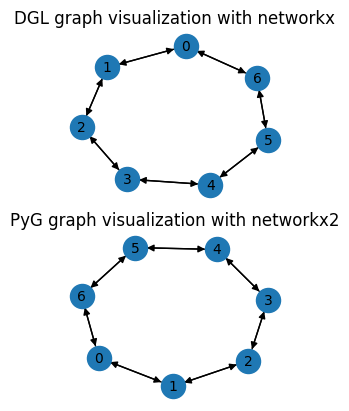

In [19]:
# build dgl graph
list_src = []
list_dst = []
num_nodes = 7
for i in range(num_nodes):
    list_src.append(i)
    list_dst.append((i+1)%num_nodes)
graph_dgl = dgl.graph((list_src, list_dst))
graph_dgl = dgl.to_bidirected(graph_dgl)
graph_nx_from_dgl = graph_dgl.to_networkx()

# build pyg graph
list_src = []
list_dst = []
num_nodes = 7
for i in range(num_nodes):
    list_src.append(i)
    list_dst.append((i+1)%num_nodes)
edge_index = torch.tensor([list_src, list_dst], dtype=torch.long)
edge_index = torch_geometric.utils.to_undirected(edge_index, num_nodes=num_nodes)
graph_pyg = Data(edge_index=edge_index, num_nodes=num_nodes)
graph_nx_from_pyg = torch_geometric.utils.to_networkx(graph_pyg)


fig = plt.figure()

###############################################
# YOUR CODE START
###############################################

ax = fig.add_subplot(221)
nx.draw(graph_nx_from_dgl, ax=ax, with_labels=True, font_size=10) # visualise node indexes
ax.title.set_text('DGL graph visualization with networkx')

ax = fig.add_subplot(223)
nx.draw(graph_nx_from_pyg, ax=ax, with_labels=True, font_size=10) # visualise node indexes
ax.title.set_text('PyG graph visualization with networkx2')


###############################################
# YOUR CODE END
###############################################

plt.show()



### Question 5.2 : Visualise the DGL graph with the eigenvectors (i.e. map a graph to a k-dim Euclidean space)

Instructions:
- Let `g` be a DGL graph.
- Use `compute_LapEig_DGL()` to get the first two eigenvectors of a DGL graph.
- Visualise the graph with the obtained two eigenvectors.
  

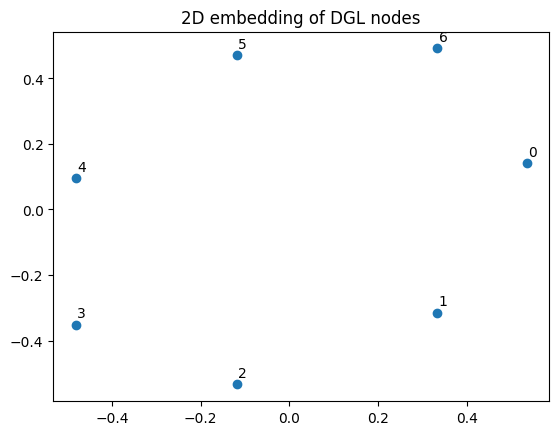

In [20]:
# Laplacian eigenvectors
def compute_LapEig_DGL(g, pos_enc_dim): # input g is a DGL graph
    # for CS5284 environment
    if dgl.__version__ =='1.0.2': 
        Adj = g.adj().to_dense() # Adjacency matrix
    # for Colab environment
    elif dgl.__version__=='2.5.0':
        Adj = g.adj_external().to_dense() # Adjacency matrix 
    Dn = ( g.in_degrees()** -0.5 ).diag() # Inverse and sqrt of degree matrix
    Lap = torch.eye(g.number_of_nodes()) - Dn.matmul(Adj).matmul(Dn) # Laplacian operator
    EigVal, EigVec = torch.linalg.eig(Lap) # Compute full EVD
    EigVal, EigVec = EigVal.real, EigVec.real # make eig real
    EigVec = EigVec[:, EigVal.argsort()] # sort in increasing order of eigenvalues
    EigVec = EigVec[:,1:pos_enc_dim+1] # select the first non-trivial "pos_enc_dim" eigenvector
    return EigVec


###############################################
# YOUR CODE START
###############################################

x = compute_LapEig_DGL(graph_dgl, 2)

###############################################
# YOUR CODE END
###############################################

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(x[:,0], x[:,1])
idx = list(range(graph_dgl.number_of_nodes()))
for i, txt in enumerate(idx):
    ax.annotate(txt, (x[:,0][i], x[:,1][i]), textcoords="offset points", xytext=(1,5))
ax.title.set_text('2D embedding of DGL nodes')
plt.show()


### Question 5.3 : Visualise the PyG graph with Laplacian eigenvectors

Instructions:
- Let `g` be a PyG graph.
- Use `compute_LapEig_PyG()` to get the first two eigenvectors of a PyG graph.
- Visualise the graph with the obtained two eigenvectors.


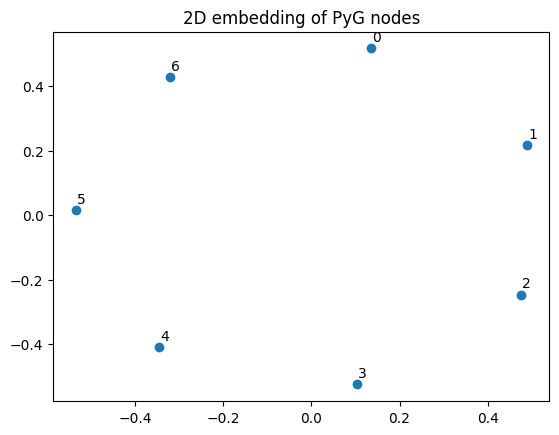

In [21]:
def compute_LapEig_PyG(data, k):
    Adj = torch_geometric.utils.to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0].float()
    deg = Adj.sum(dim=1)
    Dn = deg**-0.5
    Lap = torch.eye(data.num_nodes) - Dn.unsqueeze(1) * Adj * Dn.unsqueeze(0)
    _, EigVec = torch.linalg.eigh(Lap)
    EigVec = EigVec[:, 1:k+1]
    return EigVec


###############################################
# YOUR CODE START
###############################################

x_pyg = compute_LapEig_PyG(graph_pyg, 2)

###############################################
# YOUR CODE END
###############################################

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(x_pyg[:,0], x_pyg[:,1])
for i in range(graph_pyg.num_nodes):
    ax.annotate(i, (x_pyg[i,0], x_pyg[i,1]), textcoords="offset points", xytext=(1,5))
ax.title.set_text('2D embedding of PyG nodes')
plt.show()
